# 0.0 Установка # Обновление пакета geomml 

In [ ]:
from pathlib import Path
import os

root = Path(os.getcwd()).resolve().parents[1]  # вверх на 2 уровня
!python {str(root / "scripts" / "bootstrap.py")}

%load_ext autoreload
%autoreload 2

from hydra import initialize_config_dir, compose
from hydra.utils import instantiate

config_name = "default"

with initialize_config_dir(config_dir=str(root / "configs"), version_base="1.3"):
    cfg = compose(config_name=config_name)

# 0.1 Импорт необходимых модулей # библиотек

In [2]:
import torch, os
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

from geomml.models import build as build_model
from geomml.datasets import build as build_dataset
from geomml.losses.kendall import * 
from geomml.utils.loader import build as build_loaders
from geomml.utils.plot_history import *
from geomml.trainers.multi_task import MultiTaskTrainer
from geomml.trainers.evaluate_model import *


N_EPOCHS=1000

# 0.2 Получение информации о QM9S dataset
Набор данных **QM9Spectra (QM9S)**, содержащий 130 тысяч органических молекул, создан на основе популярного набора данных **QM9**.

Для обучения и использования доступны две версии набора данных: **.pt** (версия для torch_geometric) и **.csv**. 

Кроме того, мы также предоставляем спектры с расширенным уширением (broadened spectra).

Источники:
* https://figshare.com/articles/dataset/QM9S_dataset/24235333
* DOI: https://doi.org/10.1038/s43588-023-00550-y



In [3]:
DATA = "data"
dataset  = torch.load(os.path.join(DATA, "qm9s.pt"), map_location="cpu")
sample = dataset[0]

print(type(sample))
print(sample)
print(sample.dipole.shape)
print(sample.polar.shape)

print(type(dataset ))

print(type(dataset))
print(len(dataset))

print("\n==========================================")

all_polar = []
for data in dataset:
    all_polar.append(data.polar.view(-1))
all_polar = torch.cat(all_polar)
print("polar min:", all_polar.min())
print("polar max:", all_polar.max())
print("polar mean:", all_polar.mean())
print("polar std:", all_polar.std())

all_dipole = []
for data in dataset:
    all_dipole.append(data.dipole.view(-1))
all_dipole = torch.cat(all_dipole)
print("dipole min:", all_dipole.min())
print("dipole max:", all_dipole.max())
print("dipole mean:", all_dipole.mean())
print("dipole std:", all_dipole.std())

del dataset

<class 'torch_geometric.data.data.Data'>
Data(edge_index=[2, 20], pos=[5, 3], number=1, smile='C', z=[5], quadrupole=[1, 3, 3], octapole=[1, 3, 3, 3], npacharge=[5], dipole=[1, 3], polar=[1, 3, 3], hyperpolar=[1, 3, 3, 3], energy=[1, 1], Hij=[20, 3, 3], Hi=[5, 3, 3], dedipole=[5, 3, 3], depolar=[5, 3, 6], tran_dipole=[1, 10, 3], tran_energy=[1, 10])
torch.Size([1, 3])
torch.Size([1, 3, 3])
<class 'list'>
<class 'list'>
129817

polar min: tensor(-113.3840)
polar max: tensor(361.1190)
polar mean: tensor(27.4076)
polar std: tensor(39.7725)
dipole min: tensor(-8.5813)
dipole max: tensor(10.0062)
dipole mean: tensor(0.1989)
dipole std: tensor(1.8607)


# 0.3 [Предобработка](../../scripts/preprocess_qm9s.py) исходного QM9S датасета перед обучением модели
```python
qm9s.pt
   |
   |  Data
   |
   |  + добавляем x
   |  + меняем dipole
   |  + меняем polar
   |  + меняем класс Data -> QM9SData
   |
   ↓
qm9s_processed.pt

QM9SData:
    z
    pos
    edge_index
    x          [N_atoms,5]
    dipole     [1,3]
    polar      [1,9]
```

In [4]:
src=os.path.join(DATA,"qm9s.pt")
out=os.path.join(DATA,"qm9s_processed.pt")

if not os.path.exists(out):
    !python {str(root / "scripts" / "preprocess_qm9s.py")} {src} {out}
else:
    print(f"Already exists: {out}")

dataset=build_dataset(
    name="qm9s",
    root=os.path.join(DATA, "qm9s_processed.pt"),
    normalize=True
)
loaders=build_loaders( dataset, batch_size=64 )

Already exists: data\qm9s_processed.pt

Dataset size: 129817



### Основные [трансформации/обработки](../../src/geomml/datasets/qm9s.py) для датасета:
* нормализация таргетов
* фильтрация слабополяризуемых кейсов, у которых оси поляризуемости практическии совпадают, а значит, детерминант матрицы поляризуемости близок к нулю. Такие сингулярные случаи могут давать нестабильные градиенты и ухудшают обучение.
<!--
Однако желательно дополнительно вывести:

initial_size
filtered_size
removed_percentage


Чтобы оценить влияние фильтра.

Например:

Removed:
150 / 129817 = 0.11%


и убедиться, что фильтр не изменяет распределение данных.
-->
* строится граф соседства, вычисляется межатомные расстояния, назначается тип связи, а молекулярный граф дополняется следующими признаками:
    - формальный заряд атомов
    - признак ароматичности
    - признаки рёбер


# 0.4 Проверка перед запуском обучения

In [5]:
batch=next(iter(loaders.train))
model=build_model(name="qm9s_dimenet")
out=model(batch)

print(out["dipole"].shape)
print(out["polar"].shape)

torch.Size([64, 3])
torch.Size([64, 9])


In [6]:
data_qm9s_processed=torch.load("data/qm9s_processed.pt", map_location="cpu")

print(data_qm9s_processed[0].dipole.shape)
print(data_qm9s_processed[0].polar.shape)

torch.Size([1, 3])
torch.Size([1, 9])


In [7]:
from torch_geometric.data import Batch

b=Batch.from_data_list(
    data_qm9s_processed[:64]
)

print(type(b))
print(b.dipole.shape)
print(b.polar.shape)

<class 'abc.QM9SDataBatch'>
torch.Size([64, 1, 3])
torch.Size([64, 1, 9])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch=next(iter(loaders.train))

print(type(batch))
print(type(batch.dipole))
print(batch.dipole.shape)
print(batch.polar.shape)
print(type(data_qm9s_processed[0]))

batch=batch.to(device)
model=model.to(device)
out=model(batch)
loss=model.loss_fn(out,batch)

print(out["dipole"].shape)
print(out["polar"].shape)
print(loss)

<class 'abc.QM9SDataBatch'>
<class 'torch.Tensor'>
torch.Size([64, 1, 3])
torch.Size([64, 1, 9])
<class 'geomml.datasets.qm9s.QM9SData'>
torch.Size([64, 3])
torch.Size([64, 9])
tensor(2.1403, device='cuda:0', grad_fn=<AddBackward0>)


In [9]:
batch=next(iter(loaders.train))

print(batch.dipole.shape)
print(batch.polar.shape)

del loaders, out, model, batch, data_qm9s_processed


torch.Size([64, 1, 3])
torch.Size([64, 1, 9])


# 1. Постановка задачи

Улучшение предсказаний вектора дипольного момента и тензора поляризуемости молекул датасета [QM9s](https://figshare.com/articles/dataset/QM9S_dataset/24235333) с использованием GeomML + TDA.

Полезные ссылки по теме в [README](./README.md).

# 2. Описание модели [qm9s_dime](../../src/geomml/models/qm9s_dime.py)
Используется гибридная многозадачная графовая нейронная сеть, в которой графовая часть представлена DimeEncoder, а затем её выход объединяется с дополнительными топологическими признаками:
* общий backbone;
* две независимые ветви признаков (геометрия и TDA);
* две специализированные головы для многозадачной регрессии;
* этап объединения (torch.cat);
<!-- 
1. GeomML-признаки:
* SOAP (DScribe), 
* ACSF, 
* MBTR, 
* Coulomb Matrix 
* эмбеддинги уже существующей модели GeomML?

2. TDA:
* Persistence Diagram;
* Persistence Image;
* Persistence Landscape;
* Betti Curve.
-->
Данная архитектура учитывает расстояния и углы, что особенно важно для дипольных и поляризационных свойств молекул. 

Отдельные головы dipole_head и polar_head оправданы, поскольку задачи имеют разную физическую природу.

Натренированные модели # веса моделей будут складываться на [Google Drive](https://drive.google.com/drive/folders/1eTFydAWlC_WQYE9VyiXhglKb_BEITw_-?usp=sharing).

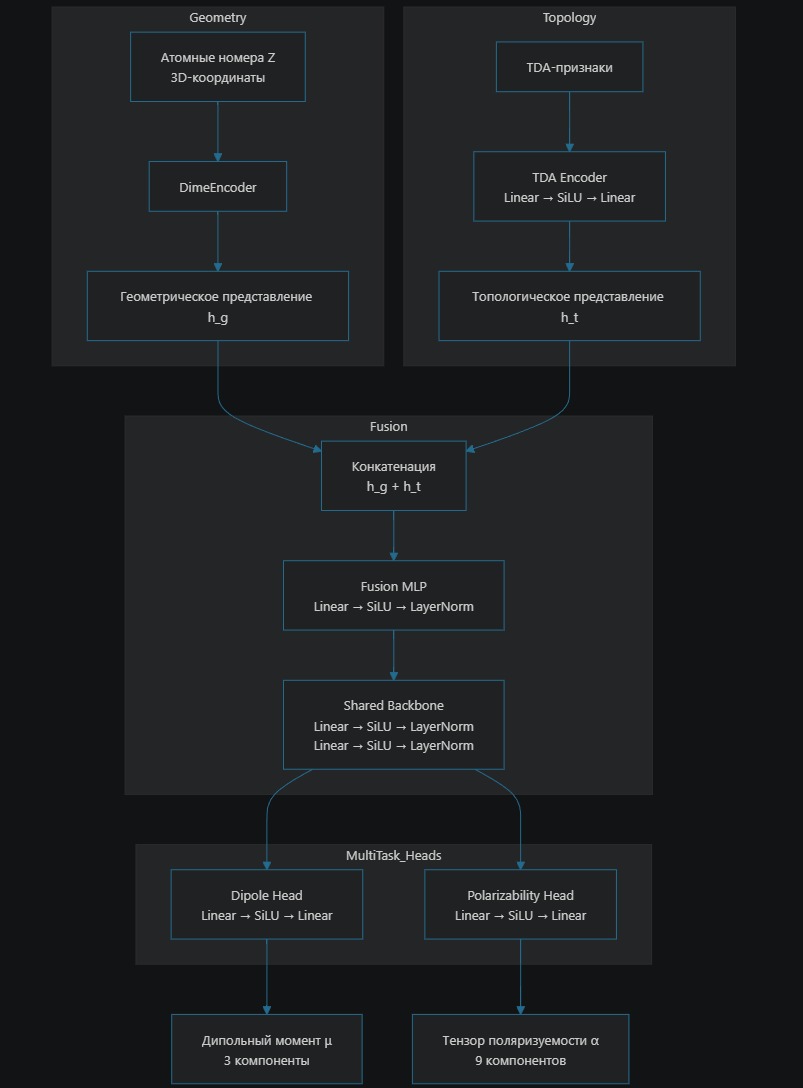

<!-- потом убрать пробелы в стрелках "- ->"
```mermaid
flowchart TB

subgraph Geometry
A[Атомные номера Z<br/>3D-координаты]
B[DimeEncoder]
C[Геометрическое представление h_g]
A - -> B - -> C
end

subgraph Topology
D[TDA-признаки]
E[TDA Encoder<br/>Linear → SiLU → Linear]
F[Топологическое представление h_t]
D - -> E - -> F
end

subgraph Fusion
G[Конкатенация<br/>h_g + h_t]
H[Fusion MLP<br/>Linear → SiLU → LayerNorm]
I[Shared Backbone<br/>Linear → SiLU → LayerNorm<br/>Linear → SiLU → LayerNorm]
G - -> H - -> I
end

C - -> G
F - -> G

subgraph MultiTask_Heads
J[Dipole Head<br/>Linear → SiLU → Linear]
K[Polarizability Head<br/>Linear → SiLU → Linear]
end

I - -> J
I - -> K

J - -> L[Дипольный момент μ<br/>3 компоненты]
K - -> M[Тензор поляризуемости α<br/>9 компонентов]
```
-->

# 3. Обучение на QM9s dataset c [Kendall loss](../../src/geomml/losses/kendall.py)

Здесь и далее в экспериментах будут применяться параметры для optimizer и scheduler из default-конфигов в директории `configs`. Конкретно, это:
```python
optimizer = AdamW (
      lr: 3e-4
      weight_decay: 1e-5
)
```
и
```python
scheduler = ReduceLROnPlateau (
    mode: min       # минимизируем val_mse
    factor: 0.5     # уменьшить LR в 2 раза
    patience: 3     # если 3 эпохи нет улучшения
    min_lr: 1e-6
)
```

### Функция потерь

Для обучения модели используется многозадачная функция потерь с автоматическим взвешиванием задач по неопределённости (**uncertainty weighting**), предложенная Kendall и Gal (2018). Модель одновременно предсказывает две физические величины:

- дипольный момент $\boldsymbol{\mu}$;
- тензор поляризуемости $\boldsymbol{\alpha}$.

Для каждой задачи вычисляется среднеквадратичная ошибка (Mean Squared Error, MSE):

$$
L_i=
\frac{1}{N_i}
\sum_{j=1}^{N_i}
(\hat y_{ij}-y_{ij})^2,
$$

где

- $\hat y_{ij}$ — предсказание модели;
- $y_{ij}$ — истинное значение;
- $i$ — индекс задачи.

Для каждой задачи вводится обучаемый параметр

$$
s_i=\log\sigma_i^2.
$$

Итоговая функция потерь определяется как

$$
L=
\frac{1}{T}
\sum_{i=1}^{T}
\left(
e^{-s_i}L_i+s_i
\right),
$$

где $T$ — число задач, присутствующих в текущем батче.


Во время обучения параметры $s_i$ оптимизируются совместно с весами нейронной сети. Это позволяет модели автоматически определять относительную важность каждой задачи. Если ошибка одной из задач существенно выше, соответствующий вес $e^{-s}$ уменьшается, снижая её вклад в общую функцию потерь. При этом слагаемое $+\,s$ препятствует неограниченному увеличению дисперсии и предотвращает вырождение решения.

В реализации модели обучаемые параметры неопределённости представлены вектором

```python
self.log_vars = nn.Parameter(torch.zeros(2))
```

где элементы `log_vars` соответствуют задачам многозадачной регрессии в порядке их обработки функцией потерь (для данной модели — прогнозирование дипольного момента и тензора поляризуемости).

В отличие от фиксированной реализации для двух задач, функция потерь вычисляется автоматически для всех предсказаний модели (за исключением внутреннего представления `repr`). Для каждой задачи вычисляется среднеквадратичная ошибка, после чего формируется суммарная функция потерь

```python
loss = 0.0

for tid, key in enumerate(task_keys):
    pred = outputs[key]
    target = getattr(batch, key)

    mse = (pred - target).pow(2).mean()
    s = model.log_vars[tid].clamp(-10, 10)

    loss += torch.exp(-s) * mse + s

loss /= n_tasks
```

Такая реализация избавляет от необходимости вручную подбирать коэффициенты между задачами, автоматически балансирует их вклад в процессе обучения и легко масштабируется на произвольное число выходных задач без изменения функции потерь.

Для повышения численной устойчивости обучаемые параметры логарифма дисперсии ограничиваются диапазоном
$$
s_i \leftarrow \operatorname{clip}(s_i,\,-10,\;10),
$$
перед вычислением функции потерь. Такое ограничение предотвращает чрезмерное увеличение или уменьшение весов отдельных задач вследствие экспоненциального множителя $e^{-s_i}$, что способствует более стабильному процессу оптимизации без изменения общей структуры функции потерь.



## hidden_dim=128, layers=4


Dataset size: 129817

Epoch [   1/1000] | TrainLoss: 0.899129 | ValidLoss: 0.849228 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 79.03s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.828822 | ValidLoss: 0.783753 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 81.14s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.784729 | ValidLoss: 0.747589 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 81.32s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.747977 | ValidLoss: 0.700846 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 80.20s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.719110 | ValidLoss: 0.684381 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 77.50s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.693228 | ValidLoss: 0.662354 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 77.83s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.669530 | ValidLoss: 0.638787 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime

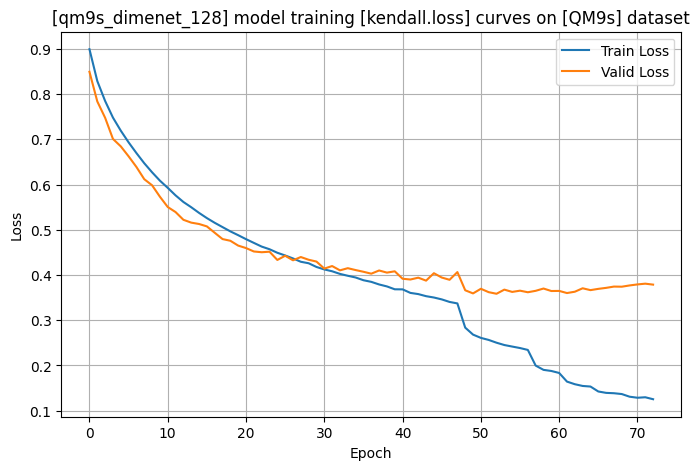

{'dipole': {'MAE': 0.53205377, 'RMSE': 0.72169334}, 'polar': {'MAE': 0.5065209, 'RMSE': 0.7213544}}


In [ ]:
from geomml.losses.kendall import * 

loaders=build_loaders( dataset, batch_size=32, train_size=0.8, valid_size=0.1)
model=build_model( "qm9s_dimenet", hidden_dim=128, layers=4 )
optimizer=instantiate( cfg.optimizer, params=model.parameters() )
scheduler=instantiate( cfg.scheduler, optimizer )

model,history=MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion = kendall_loss, # используем кастомный лосс из 'geomml/losses/kendall.py'
    patience=20,
    min_delta=1e-4,
    checkpoint_name="best_qm9s_dimenet_kendall_hdim=128_layers=4",
).fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="[qm9s_dimenet_128] model training [kendall.loss] curves on [QM9s] dataset")
print( evaluate_qm9s( model, loaders.test, device ) )

del model, loaders, optimizer, history, scheduler

## Наблюдения

### 1. Финальная оценка.
| Метрика | dipole | polar |
|---------|--------|-------|
| MAE     | 0.5321 | 0.5065 |
| RMSE    | 0.7217 | 0.7214 |


### 2. Динамика обучения.
Быстрая сходимость на начальном этапе - первые ~40 эпох наблюдается стабильное снижение ошибки:
```
Epoch 01: TrainLoss = 0.899 ValidLoss = 0.849
Epoch 40: TrainLoss = 0.368 ValidLoss = 0.408
```
Модель быстро извлекает основные закономерности из геометрического представления молекул.
Особенно важно, что validation loss уменьшается почти монотонно, разрыв между train и validation небольшой, сильного переобучения на раннем этапе нет.
Это говорит о том, что архитектура DimeNet + TDA fusion имеет достаточную выразительную способность, и регуляризация (Dropout, LayerNorm) работает.

### 3. Поведение после снижения learning rate 
на 48 эпохе scheduler уменьшает LR:
```
Epoch 47: LR = 3e-4
Epoch 48: LR = 1.5e-4
```
После этого появляется заметный скачок качества:
```
Epoch 48: ValidLoss = 0.406
Epoch 49: ValidLoss = 0.366
Epoch 53: ValidLoss = 0.358
```
То есть уменьшение learning rate позволило модели попасть в более глубокий минимум. Это показывает, что:
* первоначальный LR 3e-4 хорошо подходит для быстрого обучения;
* scheduler эффективно помогает на этапе дообучения;

### 4. Признаки переобучения. 
После ~53 эпох ситуация меняется:
```
Epoch 53: TrainLoss = 0.250  ValidLoss = 0.358
Epoch 73: TrainLoss = 0.125  ValidLoss = 0.379
```
То есть train loss продолжает падать, validation loss перестает улучшаться - появляется устойчивый разрыв. Это классический признак начала переобучения. Модель продолжает улучшать соответствие тренировочным молекулам, но перестает улучшать обобщение.

### 5. Анализ Kendall loss. 
```
После обучения: log_vars.data = tensor([-0.7920, -0.7445])
```
В Kendall uncertainty weighting используется: $𝐿 = 𝑒^{−𝑠_𝑖} 𝐿_𝑖 + 𝑠_𝑖$,  где:
* маленький $s_i$ означает большую уверенность модели в задаче;
* большой $s_i$  уменьшает вклад задачи.

Полученные значения:

| Задача | log_var |
|--------|---------|
| dipole | -0.792  |
| polar  | -0.744  |

Они близки между собой. Это означает, что баланс между задачами сохранялся во время обучения: модель не выделила одну задачу как значительно более шумную, и обе задачи имеют сопоставимую сложность. В данном случае Kendall loss действительно работает как механизм автоматического балансирования.

Основное ограничение эксперимента — раннее насыщение качества после ~50 эпох и дальнейшее переобучение. 

Для улучшения результата и получения более точных результатов можно попробовать:
* hidden_dim=256
* layers=6


## hidden_dim=256, layers=4


Dataset size: 129817

Epoch [   1/1000] | TrainLoss: 0.892896 | ValidLoss: 0.839765 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.85s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.812728 | ValidLoss: 0.777556 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.94s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.758821 | ValidLoss: 0.726704 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.19s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.713098 | ValidLoss: 0.698318 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 73.95s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.676017 | ValidLoss: 0.652470 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.08s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.641311 | ValidLoss: 0.620597 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 74.26s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.609253 | ValidLoss: 0.596531 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime

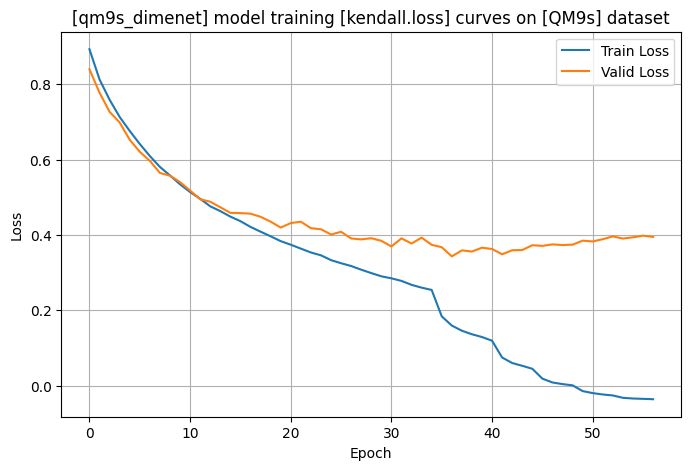

{'dipole': {'MAE': 0.5109729, 'RMSE': 0.6982398}, 'polar': {'MAE': 0.4835393, 'RMSE': 0.69636714}}


In [ ]:
from geomml.losses.kendall import * 

loaders=build_loaders( dataset, batch_size=32, train_size=0.8, valid_size=0.1)
model=build_model( "qm9s_dimenet", hidden_dim=256, layers=4 )
optimizer=instantiate( cfg.optimizer, params=model.parameters() )
scheduler=instantiate( cfg.scheduler, optimizer )

model,history=MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion = kendall_loss, # используем кастомный лосс из 'geomml/losses/kendall.py'
    patience=20,
    min_delta=1e-4,
    checkpoint_name="best_qm9s_dimenet_kendall_hdim=256_layers=4",
).fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="[qm9s_dimenet] model training [kendall.loss] curves on [QM9s] dataset")
print( evaluate_qm9s( model, loaders.test, device ) )

del model, loaders, optimizer, history, scheduler

## Наблюдения

### 1. Сравнение качества моделей.

| Метрика | hidden_dim=128 | hidden_dim=256 | Изменение |
|---------|---------------:|---------------:|-----------:|
| dipole MAE  | 0.5321 | 0.5110 | ↓ 3.9% |
| dipole RMSE | 0.7217 | 0.6982 | ↓ 3.3% |
| polar MAE   | 0.5065 | 0.4835 | ↓ 4.5% |
| polar RMSE  | 0.7214 | 0.6964 | ↓ 3.5% |

Увеличение hidden_dim в 2 раза дало стабильное улучшение всех метрик.
Наиболее заметный эффект наблюдается для задачи polar, где улучшение примерно по метрике MAE: $\frac{0.5065−0.4835}{0.5065} = 4.5 \%$

| Характеристика | hidden_dim=128 | hidden_dim=256 |
|----------------|----------------|----------------|
| Емкость модели | средняя | высокая |
| Best ValidLoss | 0.3585 | 0.3430 |
| Dipole MAE | 0.5321 | 0.5110 |
| Polar MAE | 0.5065 | 0.4835 |
| Обобщение | хорошее | лучшее |
| Переобучение | умеренное | сильное |
| Оптимальная эпоха | ~53 | ~37 |
| Kendall баланс | хороший | лучше |

### 2. Скорость сходимости. 

Интересное наблюдение: большая модель обучилась быстрее.

| Конфигурация | Лучшая эпоха | Best ValidLoss |
|--------------|-------------:|---------------:|
| hidden_dim=128 | Epoch 53 | 0.3585 |
| hidden_dim=256 | Epoch 37 | 0.3430 |

То есть модель с большей емкостью быстрее достигла лучшего минимума, потребовала меньше эпох, раньше начала переобучаться.

Это означает, что ограничением предыдущей модели была скорее недостаточная выразительность, а не недостаток регуляризации.

### 3. Поведение train/validation loss. 

У модели hidden_dim=256 наблюдается более низкие training loss и более низкий validation loss, но более сильное расхождение между train и validation.

То есть модель получила больше способности запоминать тренировочные данные.

Для `hidden_dim=128` такого резкого падения `train loss` не было. Следовательно, `hidden_dim=256` имеет значительно больший запас мощности, и регуляризация становится более важной.

### 4. Общий вывод.

**Плюсы**:
+ улучшение MAE/RMSE на обеих задачах
+ лучший validation loss
+ более быстрая сходимость
+ более эффективное использование Kendall loss
+ лучшее моделирование сложных зависимостей

**Минусы**:
- более сильное переобучение
- меньшая стабильность после оптимума
- необходимость более сильной регуляризации

Переход к `hidden_dim=256` дал заметное улучшение качества модели. Это показывает, что предыдущая версия с `hidden_dim=128` была ограничена размерностью скрытого пространства и не полностью использовала информацию из геометрического представления DimeNet.

Однако увеличение емкости привело к более быстрому переобучению: `training loss` продолжает падать почти до нуля, тогда как `validation loss` начинает расти уже после ~37 эпохи.

По текущим результатам `hidden_dim=256` является более сильной моделью и предпочтительным базовым вариантом для дальнейших экспериментов. 

Попробуем размер скрытого пространства оставить прежним, но увеличим глубину геометрического энкодера до 6 слоев.

## hidden_dim=256, layers=6


Dataset size: 129817

Epoch [   1/1000] | TrainLoss: 0.889233 | ValidLoss: 0.838924 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 92.91s | Best Model State was Saved
Epoch [   2/1000] | TrainLoss: 0.801743 | ValidLoss: 0.771326 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 93.35s | Best Model State was Saved
Epoch [   3/1000] | TrainLoss: 0.746861 | ValidLoss: 0.705513 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 95.98s | Best Model State was Saved
Epoch [   4/1000] | TrainLoss: 0.697105 | ValidLoss: 0.683964 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 95.47s | Best Model State was Saved
Epoch [   5/1000] | TrainLoss: 0.653673 | ValidLoss: 0.635485 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 95.41s | Best Model State was Saved
Epoch [   6/1000] | TrainLoss: 0.615475 | ValidLoss: 0.607117 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime: 94.92s | Best Model State was Saved
Epoch [   7/1000] | TrainLoss: 0.583230 | ValidLoss: 0.568825 | LR: 3.00e-04 | EarlyStop: 0 /20 | EpochTime

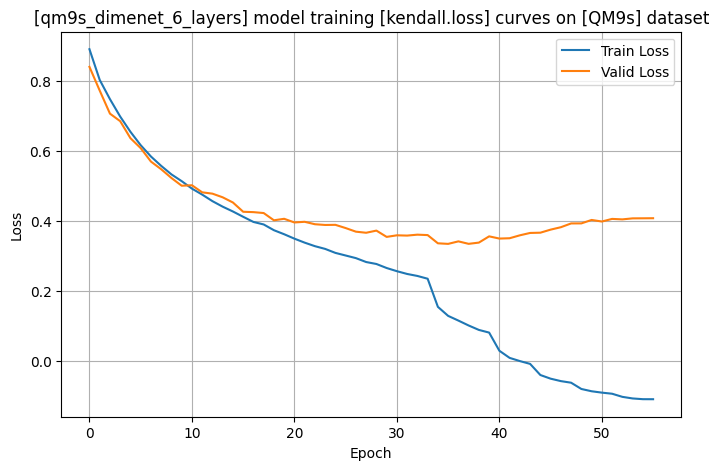

{'dipole': {'MAE': 0.51389366, 'RMSE': 0.7044682}, 'polar': {'MAE': 0.47797352, 'RMSE': 0.682737}}


In [ ]:
from geomml.losses.kendall import * 

loaders=build_loaders( dataset, batch_size=32, train_size=0.8, valid_size=0.1)
model=build_model( "qm9s_dimenet", hidden_dim=256, layers=6 )
optimizer=instantiate( cfg.optimizer, params=model.parameters() )
scheduler=instantiate( cfg.scheduler, optimizer )

model,history=MultiTaskTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion = kendall_loss, # используем кастомный лосс из 'geomml/losses/kendall.py'
    patience=20,
    min_delta=1e-4,
    checkpoint_name="best_qm9s_dimenet_kendall_hdim=256_layers=6",
).fit(
    train_loader=loaders.train,
    valid_loader=loaders.valid,
    num_epochs=N_EPOCHS
)

plot_history(history, title="[qm9s_dimenet_6_layers] model training [kendall.loss] curves on [QM9s] dataset")
print( evaluate_qm9s( model, loaders.test, device ) )

del model, loaders, optimizer, history, scheduler

## Наблюдения

### 1. Dipol
```
hidden_dim=256, layers=4: MAE = 0.5110
hidden_dim=256, layers=6: MAE = 0.5139
```
Качество практически не изменилось: $+0.6\%$. То есть увеличение количества слоев не улучшило предсказание дипольного момента. Вероятно, дипольный момент сильнее зависит от локальной геометрии.

### 2.Polar
Для поляризуемости наблюдается улучшение:
```
hidden_dim=256, layers=4: MAE  = 0.4835, RMSE = 0.6964
hidden_dim=256, layers=6: MAE  = 0.4780, RMSE = 0.6827
```

| Метрика | Улучшение |
|---------|-----------|
| Polar MAE | ↓ 1.1% |
| Polar RMSE | ↓ 2.0% |


Это показывает, что более глубокий DimeNet лучше моделирует:
* дальние взаимодействия;
* сложные зависимости между атомами;
* глобальную структуру молекулы.

Поляризуемость, в отличие от дипольного момента, сильнее зависит от распределения электронной плотности всей молекулы, поэтому глубина дает больший эффект.

### 3. Переобучение

Для `hidden_dim=256, layers=6` наблюдается еще более выраженное переобучение. Модель продолжает улучшать тренировочную ошибку, но качество на validation ухудшается.

### 4. Общий вывод

Увеличение глубины DimeNet с `layers=4` до `layers=6` при сохранении `hidden_dim=256` дало неоднозначный, но в целом положительный эффект.

Для polar модель стала лучше:
* MAE улучшился 0.4835 → 0.4780;
* RMSE улучшился 0.6964 → 0.6827;
* validation loss улучшился 0.3430 → 0.3340.

Для dipole улучшения нет: MAE немного ухудшился 0.5110 → 0.5139.

Таким образом, увеличение глубины помогает моделировать более сложные глобальные свойства молекулы  - `polar`, но практически не влияет на более локально зависимый `dipole`.


# 4. Заключение

Модель **QM9SDimeNet** была обучена на датасете QM9s размером 129817 молекул с разделением:

* train: 80%
* validation: 10%
* test: 10%

**Архитектура**:

- геометрический энкодер: DimeEncoder
- hidden_dim = 128, 256
- layers = 4, 6
- две задачи предсказания:
    - дипольный момент (dipole, размерность 3)
    - поляризуемость (polar, размерность 9)
- объединение геометрических признаков и TDA-признаков
- multi-task обучение через Kendall uncertainty weighting loss


Модель QM9SDimeNet показывает устойчивое обучение и успешно решает multi-task задачу предсказания дипольного момента и поляризуемости. Использование Kendall loss позволяет автоматически сбалансировать вклад двух физических величин, причем полученные log_vars показывают близкую сложность обеих задач.

**Итоговое сравнение**


| Характеристика | hdim=128, l=4 | hdim=256, l=4 | hdim=256, l=6 |
|----------------|---------------|---------------|---------------|
| Размер модели | средний | большой | большой + глубокий |
| Best ValidLoss | 0.3585 | 0.3430 | 0.3340 |
| Dipole MAE | 0.5321 | 0.5110 | 0.5139 |
| Polar MAE | 0.5065 | 0.4835 | 0.4780 |
| Обобщение | хорошее | лучшее | лучшее для polar |
| Переобучение | умеренное | сильное | очень сильное |
| Скорость обучения | быстрее | быстрее | медленнее |
| Сложность модели | низкая | средняя | высокая |

 Если основной критерий — минимальная ошибка на поляризуемости и общий multi-task loss, то оптимальной конфигурацией для QM9s сейчас выглядит: `hidden_dim=256, layers=6`.

**TODO: Чего поделать дальше после дедлайна:**
| Приоритет | Эксперимент | Причина |
|-----------|-------------|---------|
| 1 | увеличить Dropout(0.1 → 0.2): `hidden_dim=256, layers=6 + dropout=0.2` | прямое снижение переобучения |
| 2 | добавить weight decay: `dropout=0.2 + weight_decay=1e-5` | дополнительная регуляризация |
| 3 | уменьшить `patience=10-15` | сохранить лучший checkpoint раньше |
| 4 | `EMA/SWA` | стабилизация финальных весов |
| 5 | увеличение количество данных через дополнительные QM9-сплиты | улучшение обобщения |


Однако для практического использования стоит учитывать усиленное переобучение.